In [1]:
from datasets import load_dataset

In [2]:
ds = load_dataset(
    "Marqo/polyvore",
    split="data"
)

print(ds)

README.md:   0%|          | 0.00/4.84k [00:00<?, ?B/s]

d:\Projects\evidence_fashion_recommender\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ali29\.cache\huggingface\hub\datasets--Marqo--polyvore. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/data-00000-of-00006.parquet:   0%|          | 0.00/428M [00:00<?, ?B/s]

data/data-00001-of-00006.parquet:   0%|          | 0.00/421M [00:00<?, ?B/s]

data/data-00002-of-00006.parquet:   0%|          | 0.00/416M [00:00<?, ?B/s]

data/data-00003-of-00006.parquet:   0%|          | 0.00/416M [00:00<?, ?B/s]

data/data-00004-of-00006.parquet:   0%|          | 0.00/422M [00:00<?, ?B/s]

data/data-00005-of-00006.parquet:   0%|          | 0.00/409M [00:00<?, ?B/s]

Generating data split:   0%|          | 0/94096 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'category', 'text', 'item_ID'],
    num_rows: 94096
})


In [3]:
print(ds.features)

{'image': Image(mode=None, decode=True), 'category': Value('string'), 'text': Value('string'), 'item_ID': Value('string')}


In [4]:
sample = ds[0]
sample

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=274x400>,
 'category': 'Day Dresses',
 'text': 'tibi knit long sleeve dress',
 'item_ID': '100002074_1'}

In [5]:
import pandas as pd

df = ds.to_pandas()

df.head()

,image,category,text,item_ID
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Day Dresses,tibi knit long sleeve dress,100002074_1
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Boots,michael kors leather over-the-knee boots,100002074_2
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Handbags,givenchy leather medium antigona duffel black,100002074_3
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Sunglasses,bottega veneta acetate leather sunglasses,100002074_4
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Floral Decor,pier imports stem,100002074_5


In [6]:
df.columns.tolist()

['image', 'category', 'text', 'item_ID']

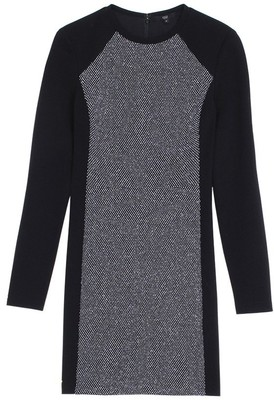

In [7]:
ds[0]['image']  # Jupyter auto-renders PIL images when they're the last line

In [10]:
df["outfit_id"] = df["item_ID"].str.split("_").str[0]

print("Items:", len(df))
print("Unique outfits:", df["outfit_id"].nunique())

df.groupby("outfit_id").size().describe()

Items: 94096
Unique outfits: 21587


count    21587.000000
mean         4.358920
std          1.739006
min          1.000000
25%          3.000000
50%          4.000000
75%          6.000000
max          8.000000
dtype: float64

In [11]:
outfit = "100002074"

df[df["outfit_id"] == outfit][
    ["item_ID", "category", "text"]
]

,item_ID,category,text
0,100002074_1,Day Dresses,tibi knit long sleeve dress
1,100002074_2,Boots,michael kors leather over-the-knee boots
2,100002074_3,Handbags,givenchy leather medium antigona duffel black
3,100002074_4,Sunglasses,bottega veneta acetate leather sunglasses
4,100002074_5,Floral Decor,pier imports stem
5,100002074_7,Coats,miranda coat


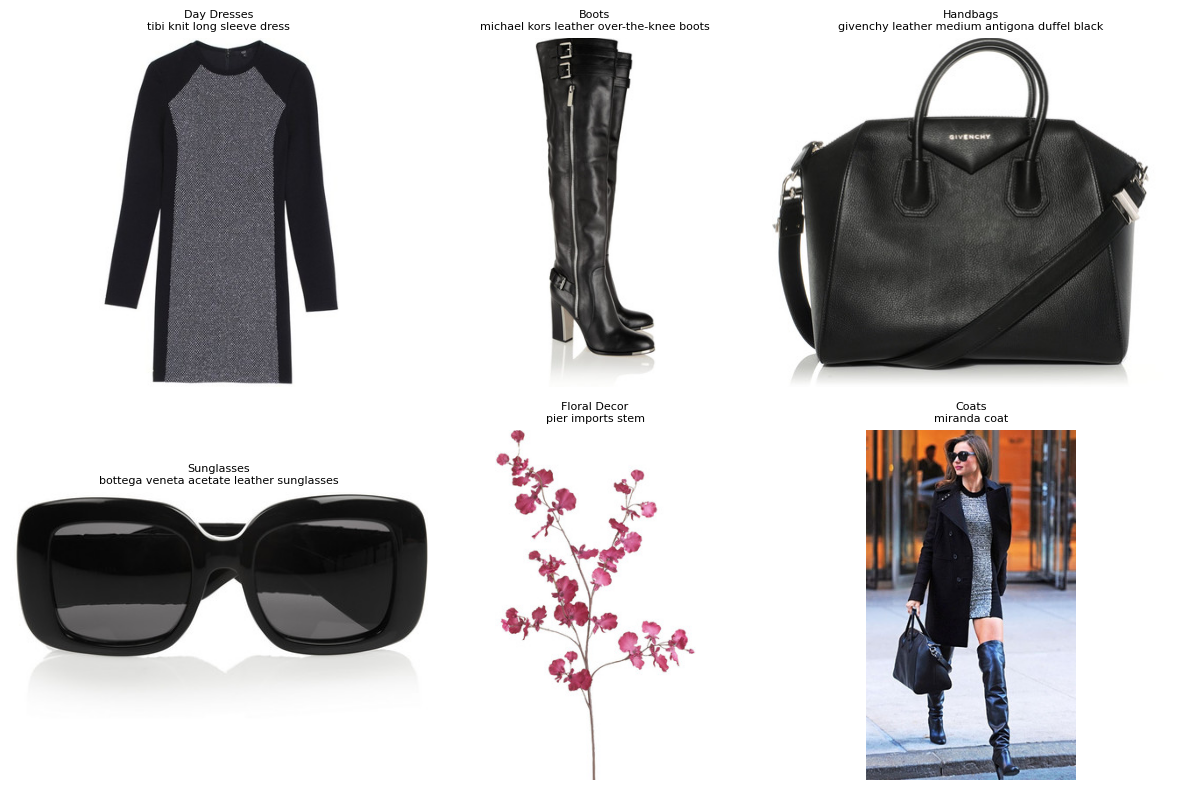

In [12]:
import matplotlib.pyplot as plt  # Import matplotlib for plotting

fig, axes = plt.subplots(2, 3, figsize=(12, 8))  # Create a 2-row, 3-column grid of subplots
axes = axes.flatten()  # Flatten the 2D array of axes into a 1D list for easy looping

for i in range(6):  # Loop over the first 6 items in the dataset
    item = ds[i]  # Grab the i-th item (image, category, text, item_ID)
    axes[i].imshow(item['image'])  # Render the image in the i-th subplot
    axes[i].set_title(f"{item['category']}\n{item['text']}", fontsize=8)  # Set category + text as title
    axes[i].axis('off')  # Hide axis ticks for a cleaner look

plt.tight_layout()  # Automatically adjust spacing so titles don't overlap
plt.show()  # Display the full grid

In [13]:
category_counts = (
    df["category"]
    .value_counts()
    .reset_index()
)

category_counts.columns = ["category", "count"]

category_counts.head(30)

,category,count
0,Earrings,3606
1,Shoulder Bags,3525
2,Necklaces,3379
3,Tops,2851
4,Sandals,2689
5,Day Dresses,2525
6,Bracelets & Bangles,2505
7,Pumps,2422
8,Clutches,2377
9,Ankle Booties,2355


In [14]:
print("Unique categories:", df["category"].nunique())

Unique categories: 377


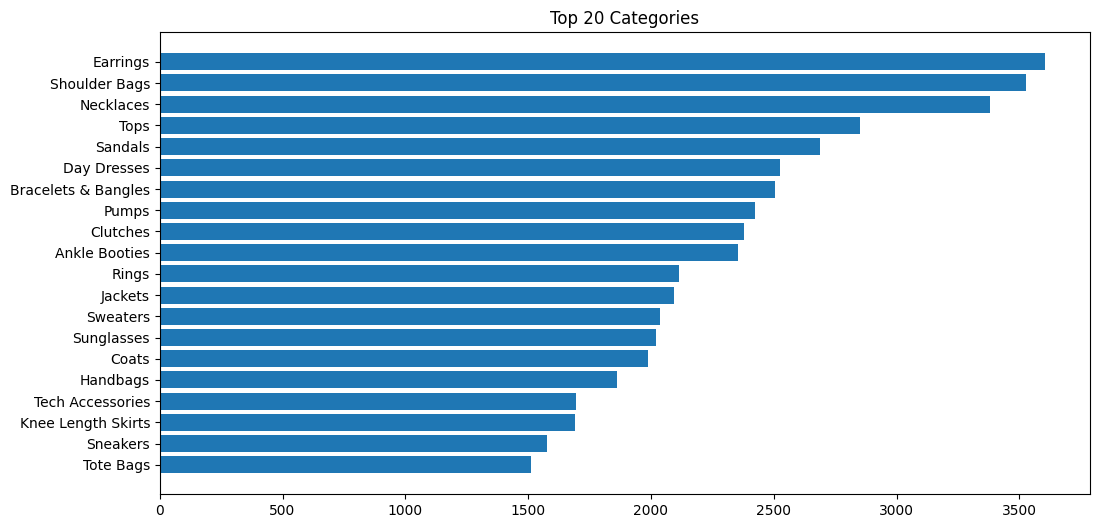

In [15]:
import matplotlib.pyplot as plt

top_n = 20

plot_df = category_counts.head(top_n)

plt.figure(figsize=(12,6))
plt.barh(plot_df["category"], plot_df["count"])
plt.title(f"Top {top_n} Categories")
plt.gca().invert_yaxis()
plt.show()